In [2]:
%pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA


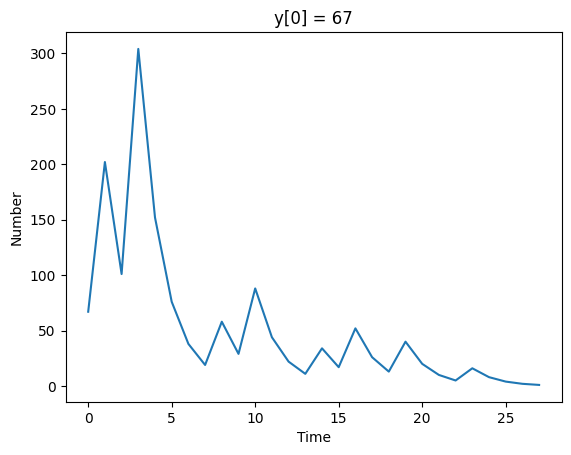

In [4]:
# generate some data
val = 67
nums = [val]
while val != 1:
    if val % 2 == 0:
        val /= 2
    else:
        val = 3 * val + 1
    nums.append(val)

# plot the data
plt.plot(nums)
plt.xlabel("Time")
plt.ylabel("Number")
plt.title("y[0] = 67")
plt.savefig("../figures/3xplus1.png")

In [5]:
# Visualization of prediction
N = 1000
series = (
    np.sin(np.linspace(0, 100, N)) + np.random.randn(N) + 0.5 * np.linspace(0, 20, N)
)

# split into past and future
future_N = 300
past = series[:-future_N]
future = series[-future_N:]

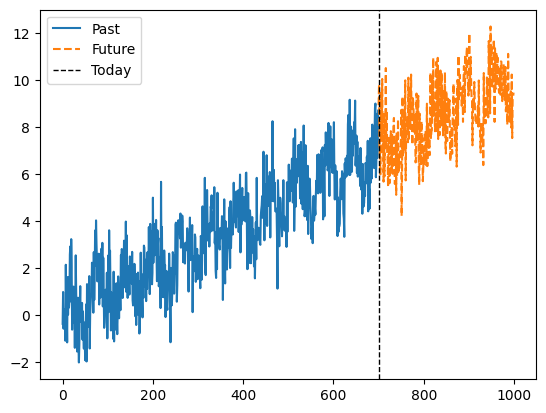

In [6]:
def plot_past_future():
    plt.plot(np.arange(N - future_N), past, label="Past")
    plt.plot(np.arange(N - future_N, N), future, "--", label="Future")
    plt.axvline(x=N - future_N, color="k", linestyle="--", linewidth=1, label="Today")


plot_past_future()
plt.legend()
plt.savefig("../figures/simple_time_series.png")

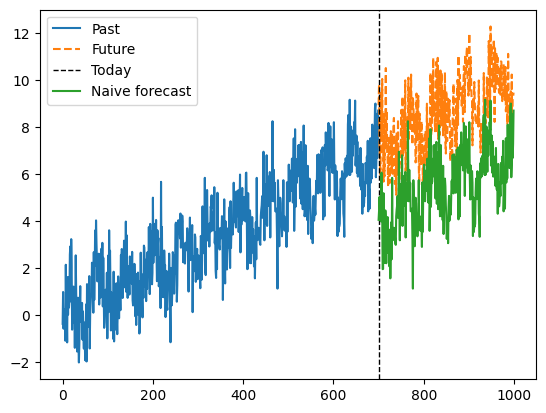

In [7]:
# Naive approach - just shift the series by some amount
naive_forecast = past[-future_N:]

plot_past_future()
plt.plot(np.arange(N - future_N, N), naive_forecast, label="Naive forecast")
plt.legend()

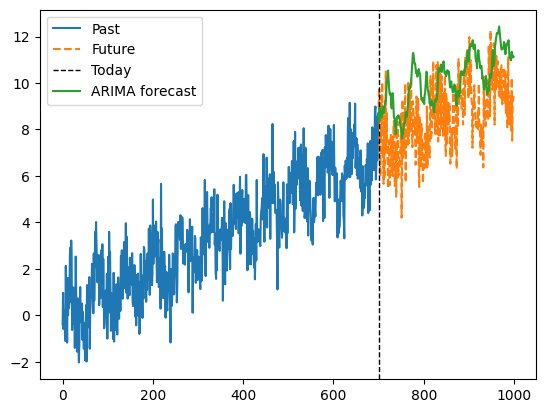

In [8]:
model = ARIMA(
    past,
    order=(1, 1, 1), # p, d, q
).fit()
pred = model.predict()[:len(future)] + past[-1]

plot_past_future()
plt.plot(np.arange(N - future_N, N), pred, label="ARIMA forecast")
plt.legend()

In [9]:
%pip install pmdarima


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
from pmdarima import auto_arima
aa_model = auto_arima(pred)

print(aa_model.order)

(0, 1, 1)


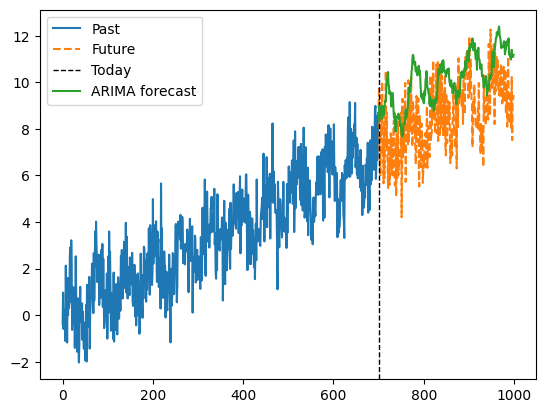

In [11]:
model = ARIMA(
    past,
    order=aa_model.order, # p, d, q
).fit()
pred = model.predict()[:len(future)] + past[-1]

plot_past_future()
plt.plot(np.arange(N - future_N, N), pred, label="ARIMA forecast")
plt.legend()

## A more realistic dataset
Traffic on Glenmore Tr SW West of Richard Rd, retrieved from [Calgary Open Data portal](https://data.calgary.ca/Transportation-Transit/Traffic-Counts-at-Permanent-stations/vuyp-sbjp/about_data).

Why 2023? I downloaded it previously and already had the CSV handy.

In [12]:
glenmore = pd.read_csv("glenmore_traffic.csv")
glenmore["STUDY_DATE"] = pd.to_datetime(
    glenmore["STUDY_DATE"], format=r"%m/%d/%Y %I:%M:%S %p"
)
glenmore.head()

,DIRECTION,STUDY_DATE,VOLUME
0,W,2023-01-01 00:00:00,72
1,E,2023-01-01 00:00:00,81
2,W,2023-01-01 00:15:00,206
3,E,2023-01-01 00:15:00,172
4,W,2023-01-01 00:30:00,274


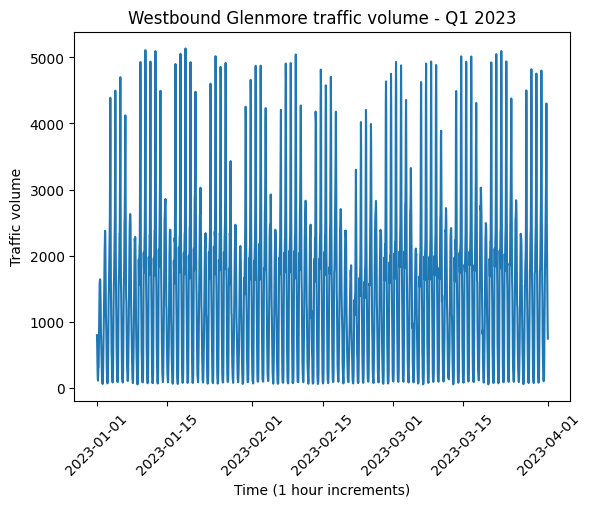

In [13]:
def filter_glenmore(start, end, dir="W"):
    # also sum over 15 minutes to get hourly values
    g = glenmore[
        (glenmore["DIRECTION"] == dir)
        & (glenmore["STUDY_DATE"] >= start)
        & (glenmore["STUDY_DATE"] < end)
    ]
    return g["STUDY_DATE"][::4].values, g["VOLUME"].values.reshape(-1, 4).sum(axis=1)

q1_dates, glenmore_wb_q1 = filter_glenmore("2023-01-01", "2023-04-01")

plt.plot(q1_dates, glenmore_wb_q1)
plt.xlabel("Time (1 hour increments)")
plt.ylabel("Traffic volume")
plt.xticks(rotation=45)
plt.title("Westbound Glenmore traffic volume - Q1 2023")
plt.savefig("../figures/08-glenmore_traffic.png")

In [14]:
# Try to forecast Q2
q2_dates, glenmore_wb_q2 = filter_glenmore("2023-04-01", "2023-07-01")

aa_model = auto_arima(glenmore_wb_q1)
print(aa_model.order)

model = ARIMA(
    glenmore_wb_q1,
    order=aa_model.order, # p, d, q
).fit()
pred = model.predict()[:len(q2_dates)]

(4, 0, 3)


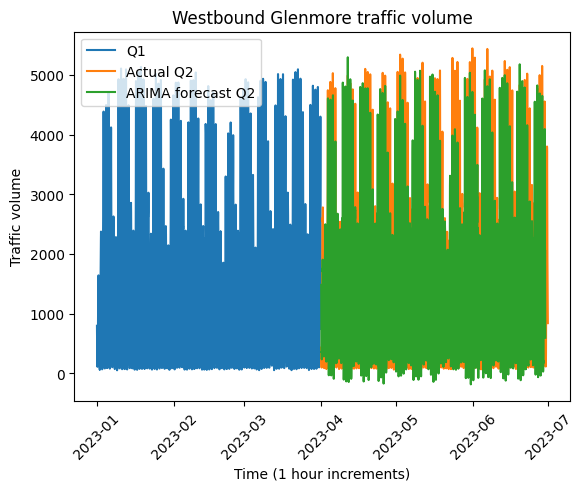

In [15]:
plt.plot(q1_dates, glenmore_wb_q1, label="Q1")
plt.plot(q2_dates, glenmore_wb_q2, label="Actual Q2")
plt.xlabel("Time (1 hour increments)")
plt.ylabel("Traffic volume")
plt.xticks(rotation=45)
plt.title("Westbound Glenmore traffic volume")
plt.plot(q2_dates[:len(pred)], pred, label="ARIMA forecast Q2")
plt.legend()


np.float64(382.15047375249486)

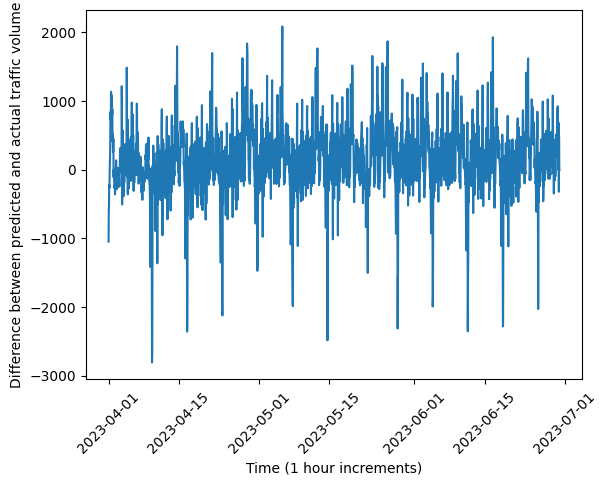

In [16]:
# what about the difference?
plt.plot(q2_dates[:len(pred)], glenmore_wb_q2[:len(pred)] - pred)
plt.xlabel("Time (1 hour increments)")
plt.ylabel("Difference between predicted and actual traffic volume")
plt.xticks(rotation=45)

# RMSE
np.mean(np.sqrt((glenmore_wb_q2[:len(pred)] - pred)**2))

## Neural network time
From the [Chapter 13 notebook](https://github.com/ageron/handson-mlp/blob/main/13_processing_sequences_using_rnns_and_cnns.ipynb) of the Hands-on ML book.

First, we need to split the data into a series of window/prediction pairs.

In [17]:
import torch
import torch.nn as nn
import torchmetrics
from helpers import *

class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end].reshape(-1, 1)
        target = self.series[end].reshape(1,)
        return window, target

In [18]:
# demonstrate what it does - dimensionality kinda weird
my_series = torch.tensor(np.arange(5))
my_dataset = TimeSeriesDataset(my_series, window_length=3)
for window, target in my_dataset:
    print("Window:", window, " Target:", target)


Window: tensor([[0],
        [1],
        [2]])  Target: tensor([3])
Window: tensor([[1],
        [2],
        [3]])  Target: tensor([4])


(tensor([[0.1596],
        [0.1346],
        [0.0846],
        [0.0540],
        [0.0272],
        [0.0220],
        [0.0408],
        [0.0628],
        [0.0630],
        [0.1138],
        [0.1806],
        [0.2342],
        [0.2720],
        [0.3168],
        [0.3230],
        [0.3286],
        [0.3240],
        [0.2822],
        [0.2448],
        [0.1674],
        [0.1496],
        [0.1204],
        [0.0766],
        [0.0656]]), tensor([0.0348]))
(tensor([[0.1346],
        [0.0846],
        [0.0540],
        [0.0272],
        [0.0220],
        [0.0408],
        [0.0628],
        [0.0630],
        [0.1138],
        [0.1806],
        [0.2342],
        [0.2720],
        [0.3168],
        [0.3230],
        [0.3286],
        [0.3240],
        [0.2822],
        [0.2448],
        [0.1674],
        [0.1496],
        [0.1204],
        [0.0766],
        [0.0656],
        [0.0348]]), tensor([0.0212]))


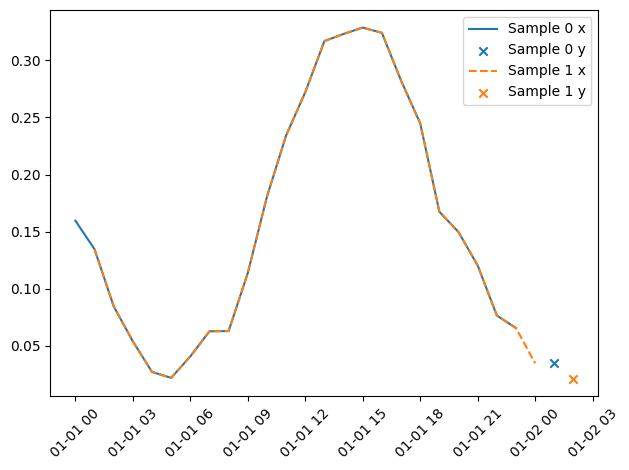

In [19]:
# create data loaders for the traffic data
window = 24

# also scale to a more reasonable range
max_vol = 5000
wb_q1_tensor = torch.FloatTensor(glenmore_wb_q1.astype(float) / max_vol)
wb_q2_tensor = torch.FloatTensor(glenmore_wb_q2.astype(float) / max_vol)

# split q2 in half for val/test
half = len(wb_q2_tensor) // 2

traffic_train = TimeSeriesDataset(wb_q1_tensor, window_length=window)
traffic_val = TimeSeriesDataset(wb_q2_tensor[:half], window_length=window)
traffic_test = TimeSeriesDataset(wb_q2_tensor[half:], window_length=window)

fig, ax = plt.subplots(1, 1)
t_it = iter(traffic_train)

for i in range(2):
    batch = next(t_it)
    print(batch)
    x = batch[0]
    y = batch[1]

    ls = '-'
    if i == 1:
        ls = '--'
    ax.plot(q1_dates[i:i+window], x, label=f"Sample {i} x", linestyle=ls)
    ax.scatter(q1_dates[window+i+1], y, label=f"Sample {i} y", marker="x")
    ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

## Basic NN
Before RNN, can we make this prediction work with a simple NN?

In [20]:
# create data loaders with batches
from torch.utils.data import DataLoader
torch.manual_seed(0)
train_loader = DataLoader(traffic_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(traffic_val, batch_size=32)
test_loader = DataLoader(traffic_test, batch_size=32)

In [21]:
fcn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=window, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=1)
)

device = get_device()
n_epochs = 20
optimizer = torch.optim.Adam(fcn_model.parameters())
loss = nn.HuberLoss()
metric = torchmetrics.MeanAbsoluteError()
history = train(
    fcn_model,
    optimizer,
    loss,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device,
)

Epoch 1/20, train loss: 0.0159, train metric: 0.1427, valid metric: 0.0961
Epoch 2/20, train loss: 0.0055, train metric: 0.0821, valid metric: 0.0749
Epoch 3/20, train loss: 0.0039, train metric: 0.0686, valid metric: 0.0668
Epoch 4/20, train loss: 0.0031, train metric: 0.0593, valid metric: 0.0580
Epoch 5/20, train loss: 0.0025, train metric: 0.0515, valid metric: 0.0522
Epoch 6/20, train loss: 0.0021, train metric: 0.0465, valid metric: 0.0478
Epoch 7/20, train loss: 0.0019, train metric: 0.0426, valid metric: 0.0453
Epoch 8/20, train loss: 0.0017, train metric: 0.0395, valid metric: 0.0428
Epoch 9/20, train loss: 0.0015, train metric: 0.0377, valid metric: 0.0411
Epoch 10/20, train loss: 0.0014, train metric: 0.0360, valid metric: 0.0396
Epoch 11/20, train loss: 0.0013, train metric: 0.0348, valid metric: 0.0390
Epoch 12/20, train loss: 0.0013, train metric: 0.0340, valid metric: 0.0371
Epoch 13/20, train loss: 0.0012, train metric: 0.0328, valid metric: 0.0363
Epoch 14/20, train lo

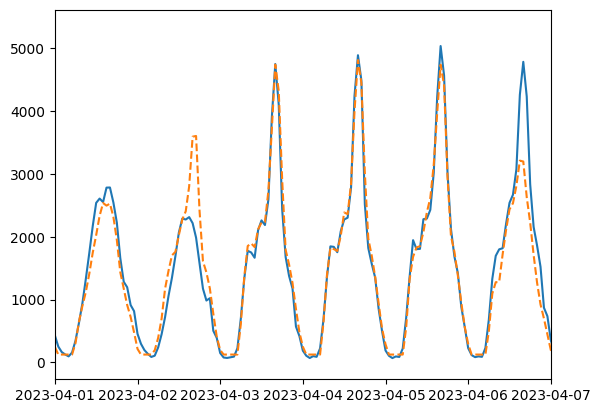

In [22]:
def plot_prediction(model):
    # polluting with all kinds of global variables
    pred = np.zeros_like(glenmore_wb_q2[:half])
    i = 0
    # make a temporary data loader with just 1 batch
    val_loader = DataLoader(traffic_val, batch_size=1)
    for X_batch, _ in val_loader:
        batch_pred = model(X_batch)
        pred[i] = batch_pred[0] * max_vol
        i += 1

    plt.plot(q2_dates[:half], glenmore_wb_q2[:half], label="Actual")
    plt.plot(q2_dates[:half], pred[:half], linestyle="--", label="Predicted")
    plt.xlim(np.datetime64("2023-04-01"), np.datetime64("2023-04-07"))

plot_prediction(fcn_model)

In [23]:
# Now define an RNN
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])

simple_rnn = SimpleRnnModel(1, 8, 1)
device = get_device()
n_epochs = 20
optimizer = torch.optim.Adam(simple_rnn.parameters())
loss = nn.HuberLoss()
metric = torchmetrics.MeanAbsoluteError()
history = train(
    simple_rnn,
    optimizer,
    loss,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device,
)

Epoch 1/20, train loss: 0.0390, train metric: 0.2135, valid metric: 0.1925
Epoch 2/20, train loss: 0.0209, train metric: 0.1600, valid metric: 0.1471
Epoch 3/20, train loss: 0.0126, train metric: 0.1201, valid metric: 0.1036
Epoch 4/20, train loss: 0.0087, train metric: 0.0910, valid metric: 0.0842
Epoch 5/20, train loss: 0.0073, train metric: 0.0794, valid metric: 0.0777
Epoch 6/20, train loss: 0.0063, train metric: 0.0745, valid metric: 0.0723
Epoch 7/20, train loss: 0.0055, train metric: 0.0699, valid metric: 0.0686
Epoch 8/20, train loss: 0.0049, train metric: 0.0669, valid metric: 0.0652
Epoch 9/20, train loss: 0.0045, train metric: 0.0643, valid metric: 0.0637
Epoch 10/20, train loss: 0.0042, train metric: 0.0627, valid metric: 0.0645
Epoch 11/20, train loss: 0.0040, train metric: 0.0613, valid metric: 0.0614
Epoch 12/20, train loss: 0.0037, train metric: 0.0593, valid metric: 0.0606
Epoch 13/20, train loss: 0.0036, train metric: 0.0584, valid metric: 0.0592
Epoch 14/20, train lo

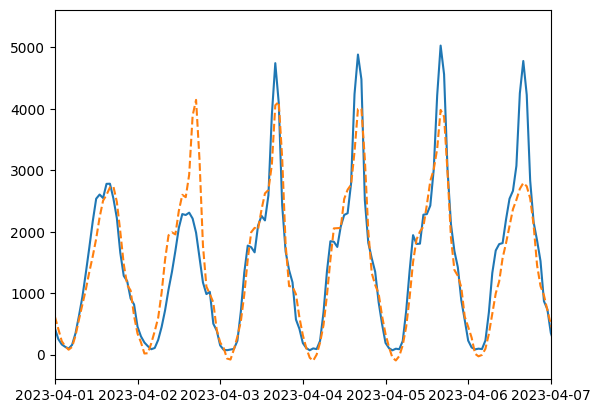

In [24]:
plot_prediction(simple_rnn)

In [25]:
# Go deeper?
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])

deeper_rnn = DeepRnnModel(1, 8, 1, 3)
n_epochs = 20
optimizer = torch.optim.Adam(deeper_rnn.parameters())
loss = nn.HuberLoss()
metric = torchmetrics.MeanAbsoluteError()
history = train(
    deeper_rnn,
    optimizer,
    loss,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device,
)

Epoch 1/20, train loss: 0.0302, train metric: 0.1987, valid metric: 0.1902
Epoch 2/20, train loss: 0.0157, train metric: 0.1361, valid metric: 0.0779
Epoch 3/20, train loss: 0.0046, train metric: 0.0624, valid metric: 0.0672
Epoch 4/20, train loss: 0.0037, train metric: 0.0568, valid metric: 0.0521
Epoch 5/20, train loss: 0.0029, train metric: 0.0501, valid metric: 0.0484
Epoch 6/20, train loss: 0.0023, train metric: 0.0458, valid metric: 0.0462
Epoch 7/20, train loss: 0.0019, train metric: 0.0440, valid metric: 0.0444
Epoch 8/20, train loss: 0.0017, train metric: 0.0415, valid metric: 0.0423
Epoch 9/20, train loss: 0.0015, train metric: 0.0403, valid metric: 0.0431
Epoch 10/20, train loss: 0.0014, train metric: 0.0389, valid metric: 0.0411
Epoch 11/20, train loss: 0.0014, train metric: 0.0390, valid metric: 0.0418
Epoch 12/20, train loss: 0.0013, train metric: 0.0384, valid metric: 0.0398
Epoch 13/20, train loss: 0.0013, train metric: 0.0378, valid metric: 0.0408
Epoch 14/20, train lo

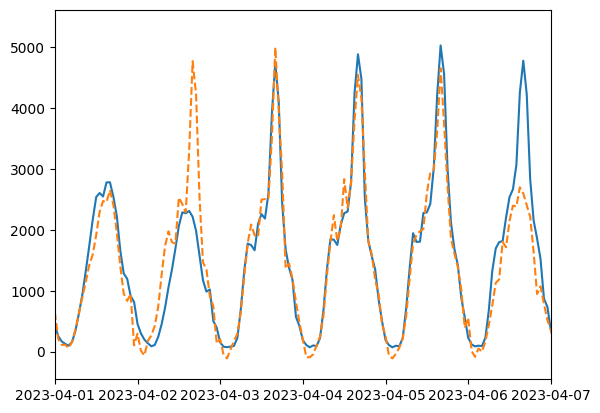

In [27]:
plot_prediction(deeper_rnn)